Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.7679 - loss: 0.4818 - val_accuracy: 0.8670 - val_loss: 0.3248
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8905 - loss: 0.2644 - val_accuracy: 0.8704 - val_loss: 0.3070
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9135 - loss: 0.2164 - val_accuracy: 0.8728 - val_loss: 0.3027
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9325 - loss: 0.1784 - val_accuracy: 0.8540 - val_loss: 0.3670
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9460 - loss: 0.1517 - val_accuracy: 0.8468 - val_loss: 0.4265
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8331 - loss: 0.4459

Accuracy: 0.833079993724823
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

Sample Predictions:

Review 1
Actual: Negative
Predicted: Positive

Review 2
Actual: Positive
Predicted: Positive

Review 3
Actual: Positive
Predicted: Positive

Review 4
Actual: Negative
Predicted: Negative

Revi

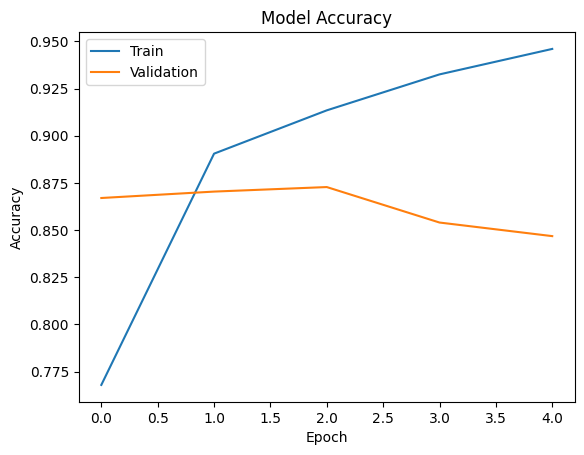

In [3]:
# Binary Classification using DNN
# IMDB Movie Review Sentiment Analysis

# Import Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load IMDB Dataset
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

# Pad Sequences
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

# Build DNN Model
model = Sequential([
    
    Embedding(vocab_size, 32, input_length=max_length),

    GlobalAveragePooling1D(),

    Dense(64, activation='relu'),

    Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("\nAccuracy:", accuracy)

# Predict Reviews
predictions = model.predict(X_test)

predicted_labels = (predictions > 0.5).astype("int32")

# Show Sample Predictions
print("\nSample Predictions:\n")

for i in range(5):

    actual = "Positive" if y_test[i] == 1 else "Negative"

    predicted = "Positive" if predicted_labels[i] == 1 else "Negative"

    print(f"Review {i+1}")
    print("Actual:", actual)
    print("Predicted:", predicted)
    print()

# Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()